<h1 style="text-align:center; color:green; font-size:48px;">
STEP 5A - OEMOF
</h1>

### Support functions

In [1]:
# Levelized Cost of Heat

def LCOH(invest_cost, operation_cost, heat_produced, revenue=0, i=0.05, n=20):
    pvf = ((1 + i) ** n - 1) / ((1 + i) ** n * i)

    return (invest_cost + pvf * (operation_cost - revenue)) / (
        pvf * heat_produced
    )
    
# Equivalent Periodic Cost

def epc(invest_cost, i=0.05, n=20):
    af = (i * (1 + i) ** n) / ((1 + i) ** n - 1)

    return invest_cost * af

# Import libraries

In [2]:
import os
import openpyxl
import warnings
import logging
import pandas as pd
import matplotlib.pyplot as plt
from oemof.solph import (Bus, EnergySystem, Flow, Model, create_time_index, processing, Investment, NonConvex)
from oemof.solph.components import (Sink, Source, Converter, GenericStorage)
from oemof.solph import EnergySystem
from oemof.solph import views
from oemof.network.graph import create_nx_graph
import oemof.solph as solph

## 1.1 Create the energy system

In [3]:
# CO2 price [EUR/tCO2]
co2_price = 83.79 #EURO/TON

# Emission factors [tCO2 / MWh fuel]
emission_factor_chp = 0.648   # gas CHP 0.18 kg/MJ  FOR GAS BOILER AND GAS CHP
emission_factor_biomass = 0  # BIOMASS
emission_factor_grid = 0.033 # for boiler and HP

emission_factor_grid_EB = emission_factor_grid / 0.99 # for boiler and HP
emission_factor_grid_HP = emission_factor_grid / 4 #hp



# read the input data file
filename = r"Input_file_S5A/Input_OEMOF.csv"
data = pd.read_csv(filename)

# specifying the solver
solver = "gurobi"
solver_verbose = False

# Create energy system
datetimeindex = create_time_index(2022, number=len(data)) # By default, the function creates an hourly index for one year.
energysystem = EnergySystem(timeindex=datetimeindex, infer_last_interval=False)

# Add components to the energy system
# Buses
electrical_bus = Bus(label="electrical_bus") # Electricity bus
thermal_bus = Bus(label="thermal_bus") # Heat bus
gas_bus = Bus(label="gas_bus") # Natural gas bus
biomass_bus = Bus(label = 'bio_bus') #Biomass bus

energysystem.add(electrical_bus, thermal_bus, gas_bus, biomass_bus)

# Gas source with cost from gas
energysystem.add(
    Source(label="natural_gas",outputs={gas_bus: Flow(variable_costs=data["gas_price"] / 1000)})
                )

# Grid electricity source
energysystem.add(
    Source(label="electricity_grid", outputs={electrical_bus: Flow(variable_costs=data["electricity_price"])})
                )

#Biomass source
energysystem.add(
    Source(label="wood_pellets", outputs={biomass_bus: Flow(variable_costs=data["wp_price"])})
)

# Thermal demand sink
energysystem.add(
    Sink(
        label="thermal_demand",
        inputs={thermal_bus: Flow(
            nominal_value=5591.0759,  #nominal value [kW]
            fix=data["thermal_demand"]
        )},
    )
)


# Producer 1 - Electric boiler
energysystem.add(
    Converter(
        label="electric_boiler",
        inputs={electrical_bus: Flow()},
        outputs={
            thermal_bus: 
            Flow(
                variable_costs= 0.8e-3 + emission_factor_grid_EB * co2_price / 1000,  # EUR/kWh, #O&M cost [EUR/kW]
                #INVESTMENT
                investment=Investment(
                    ep_costs = 150, #CAPEX [EUR/kW_el]
                    minimum = 60, #min capacity [kW]
                    maximum = 5000 #max capacity [kW]
                ),
                #OPERATIONAL VALUES
                min = 0.05, #minimum load [%]
                max=1, #maximum load [%]
                
            )
        },
        conversion_factors={thermal_bus: 0.99}
    )
)


# Producer 2 - Gas boiler
energysystem.add(
    Converter(
        label="gas_boiler",
        inputs={gas_bus: Flow()},
        outputs={
            thermal_bus: 
            Flow(
                variable_costs= 1.1e-3 + emission_factor_chp * co2_price / 1000, #O&M cost [EUR/kW]
                #INVESTMENT
                investment=Investment(
                    ep_costs = 60, #CAPEX [EUR/kW_el]
                    minimum = 500, #min capacity [kW]
                    maximum = 10000 #max capacity [kW]
                ),
                #OPERATIONAL VALUES
                min = 0.15, #minimum load [%]
                max=1, #maximum load [%]

              
            )
        },
        conversion_factors={thermal_bus: 1.05}
    )
)

# Producer 3 - Gas CHP - Simple cycle, backpressure
energysystem.add(
    Converter(
        label="gas_chp",
        inputs={gas_bus: Flow()},
        outputs={
            electrical_bus: 
            Flow(
                variable_costs= 5.5e-3 + emission_factor_chp * co2_price / 1000, #O&M cost [EUR/kWh]
                #INVESTMENT
                investment=Investment(
                    ep_costs = 750, #CAPEX [EUR/kW_el]
                    minimum = 500, #min capacity [kW]
                    maximum = 40000 #max capacity [kW]
                ),
                #OPERATIONAL VALUES
                min = 0.25, #minimum load [%]
                max=1, #maximum load [%]

                nonconvex=NonConvex(
                    minimum_uptime=4,    # once started, stay ON ≥ min_uptime time steps 
                    minimum_downtime=4,  # once stopped, stay OFF ≥ max_uptime time steps 
                    
                ),
            ),
            thermal_bus: Flow()
        },
        conversion_factors={electrical_bus: 0.37, thermal_bus: 0.52}
    )
)

# Producer 4 - Biomass CHP - Small wood pellet plant
energysystem.add(
    Converter(
        label="biomass_chp",
        inputs={biomass_bus: Flow()},
        outputs={
            electrical_bus: 
            Flow(
                variable_costs= 3.9e-3 + emission_factor_biomass * co2_price / 1000, #O&M cost [EUR/kWh]
                #INVESTMENT
                investment=Investment(
                    ep_costs = 6200, #CAPEX [EUR/kW_el]
                    minimum = 190, #min capacity [kW]
                    maximum = 3100 #max capacity [kW]
                ),
                #OPERATIONAL VALUES
                min = 0.2, #minimum load [%]
                max=1, #maximum load [%]

                nonconvex=NonConvex(
                    minimum_uptime=6,    # once started, stay ON ≥ min_uptime time steps 
                    minimum_downtime=6,  # once stopped, stay OFF ≥ max_uptime time steps 
                    initial_status=0,    # 0 = OFF at start, 1 = ON 
                    
                ),
            ),
            thermal_bus: Flow()
        },
        conversion_factors={electrical_bus: 0.154, thermal_bus: 0.855}
    )
)

# Producer 5 - Heat pump
energysystem.add(
    Converter(
        label="heat_pump",
        inputs={electrical_bus: Flow()},
        outputs={
            thermal_bus: 
            Flow(
                variable_costs= 3.75 +  emission_factor_grid_HP * co2_price / 1000, #O&M cost [EUR/kWh]
                #INVESTMENT
                investment=Investment(
                    ep_costs = 1720, #CAPEX [EUR/kW_el]
                    minimum = 500, #min capacity [kW]
                    maximum = 1000 #max capacity [kW]
                ),
                #OPERATIONAL VALUES
                min = 0.75, #minimum load [%]
                max=1, #maximum load [%]
              
            )
        },
        conversion_factors={thermal_bus: 4}
    )
)



c:\Users\rodri\anaconda3\envs\env_P2\lib\site-packages\oemof\solph\flows\_flow.py:163: FutureWarning: For backward compatibility, the option investment overwrites the option nominal_value. Both options cannot be set at the same time.
  warn(msg, FutureWarning)


## 1.2 Build and solve model

In [ ]:
model = Model(energysystem)


logging.info("Solving the optimization problem.")
model.solve(
    solver='cbc',
    solve_kwargs={"tee": True},
    cmdline_options={"ratioPGap": 0.02}
)

'''
This returns a dictionary containing time series and scalar results for all components (buses, converters, sources, etc.).
Or view results for a specific node (for example, a bus).
'''

# Process results
energysystem.results["main"] = processing.results(model)
energysystem.results["meta"] = processing.meta_results(model)

# Save results to file
output_file = os.path.join(os.getcwd(), "Output_file_S5A_copy/results.oemof")

energysystem.dump(os.getcwd(), "Output_file_S5A_copy/results.oemof")

logging.info("Results have been dumped.")

Read LP format model from file C:\Users\rodri\AppData\Local\Temp\tmphynwg8az.pyomo.lp
Reading time = 0.97 seconds
x1: 271539 rows, 166448 columns, 761932 nonzeros
Set parameter MIPGap to value 0.02
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i5-7300HQ CPU @ 2.50GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 4 logical processors, using up to 4 threads

Non-default parameters:
MIPGap  0.02

Academic license 2754901 - for non-commercial use only - registered to ro___@kth.se
Optimize a model with 271539 rows, 166448 columns and 761932 nonzeros
Model fingerprint: 0x5a4fa3c0
Variable types: 148928 continuous, 17520 integer (17520 binary)
Coefficient statistics:
  Matrix range     [5e-02, 4e+04]
  Objective range  [4e-03, 6e+03]
  Bounds range     [1e+00, 4e+04]
  RHS range        [4e+00, 4e+04]
Presolve removed 78847 rows and 87603 columns
Presolve time: 2.41s
Presolved: 192692 rows, 78845 columns, 5883

c:\Users\rodri\anaconda3\envs\env_P2\lib\site-packages\oemof\network\energy_system.py:256: FutureWarning: Parameter 'dpath' will be removed in a future version. You can give the directory as part of the filename and set 'consider_dpath' to False to suppress this waring.
  warnings.warn(


## 1.3 Results

Export to excel

In [5]:
from oemof.solph import processing, views

results_ex = processing.results(model)

import pandas as pd

with pd.ExcelWriter("OEMOF_main_results_copy.xlsx", engine="openpyxl") as writer:

    # Electricity bus flows
    views.node(results_ex, "electrical_bus")["sequences"].to_excel(
        writer, sheet_name="Electricity"
    )

    # Heat bus flows
    views.node(results_ex, "thermal_bus")["sequences"].to_excel(
        writer, sheet_name="Heat"
    )

    # Gas bus flows
    views.node(results_ex, "gas_bus")["sequences"].to_excel(
        writer, sheet_name="Gas"
    )

    # Biomass bus flows
    views.node(results_ex, "bio_bus")["sequences"].to_excel(
        writer, sheet_name="Biomass"
    )
with pd.ExcelWriter("OEMOF_capacities_copy.xlsx", engine="openpyxl") as writer:

    for comp in ["electric_boiler", "gas_boiler", "gas_chp", "biomass_chp", "heat_pump"]:
        node_view = views.node(results_ex, comp)
        
        # If scalars exist (investable units)
        if "scalars" in node_view and not node_view["scalars"].empty:
            node_view["scalars"].to_excel(writer, sheet_name=comp)
        else:
            # fallback: export the flows instead
            flows = node_view.get("sequences", pd.DataFrame())
            if not flows.empty:
                flows.to_excel(writer, sheet_name=comp)
            else:
                # nothing to export
                pd.DataFrame({"Info": [f"No scalars or flows for {comp}"]}).to_excel(writer, sheet_name=comp)

objective_value = model.objective()
pd.DataFrame(
    {"Total system cost [EUR]": [objective_value]}
).to_excel("OEMOF_objective_copy.xlsx", index=False)

### Analyse thermal node

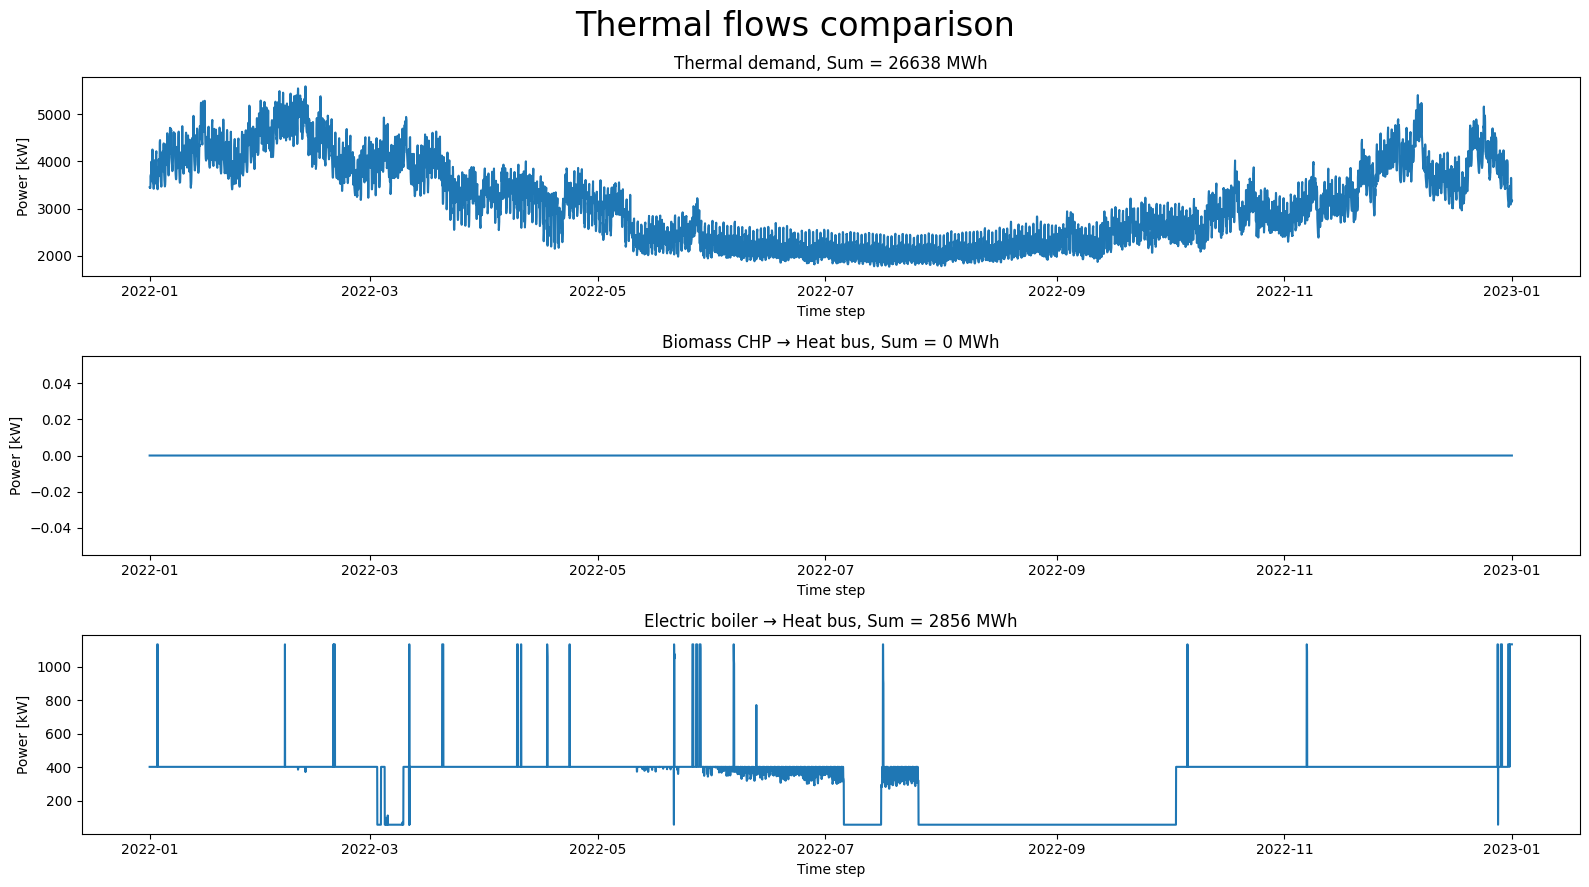

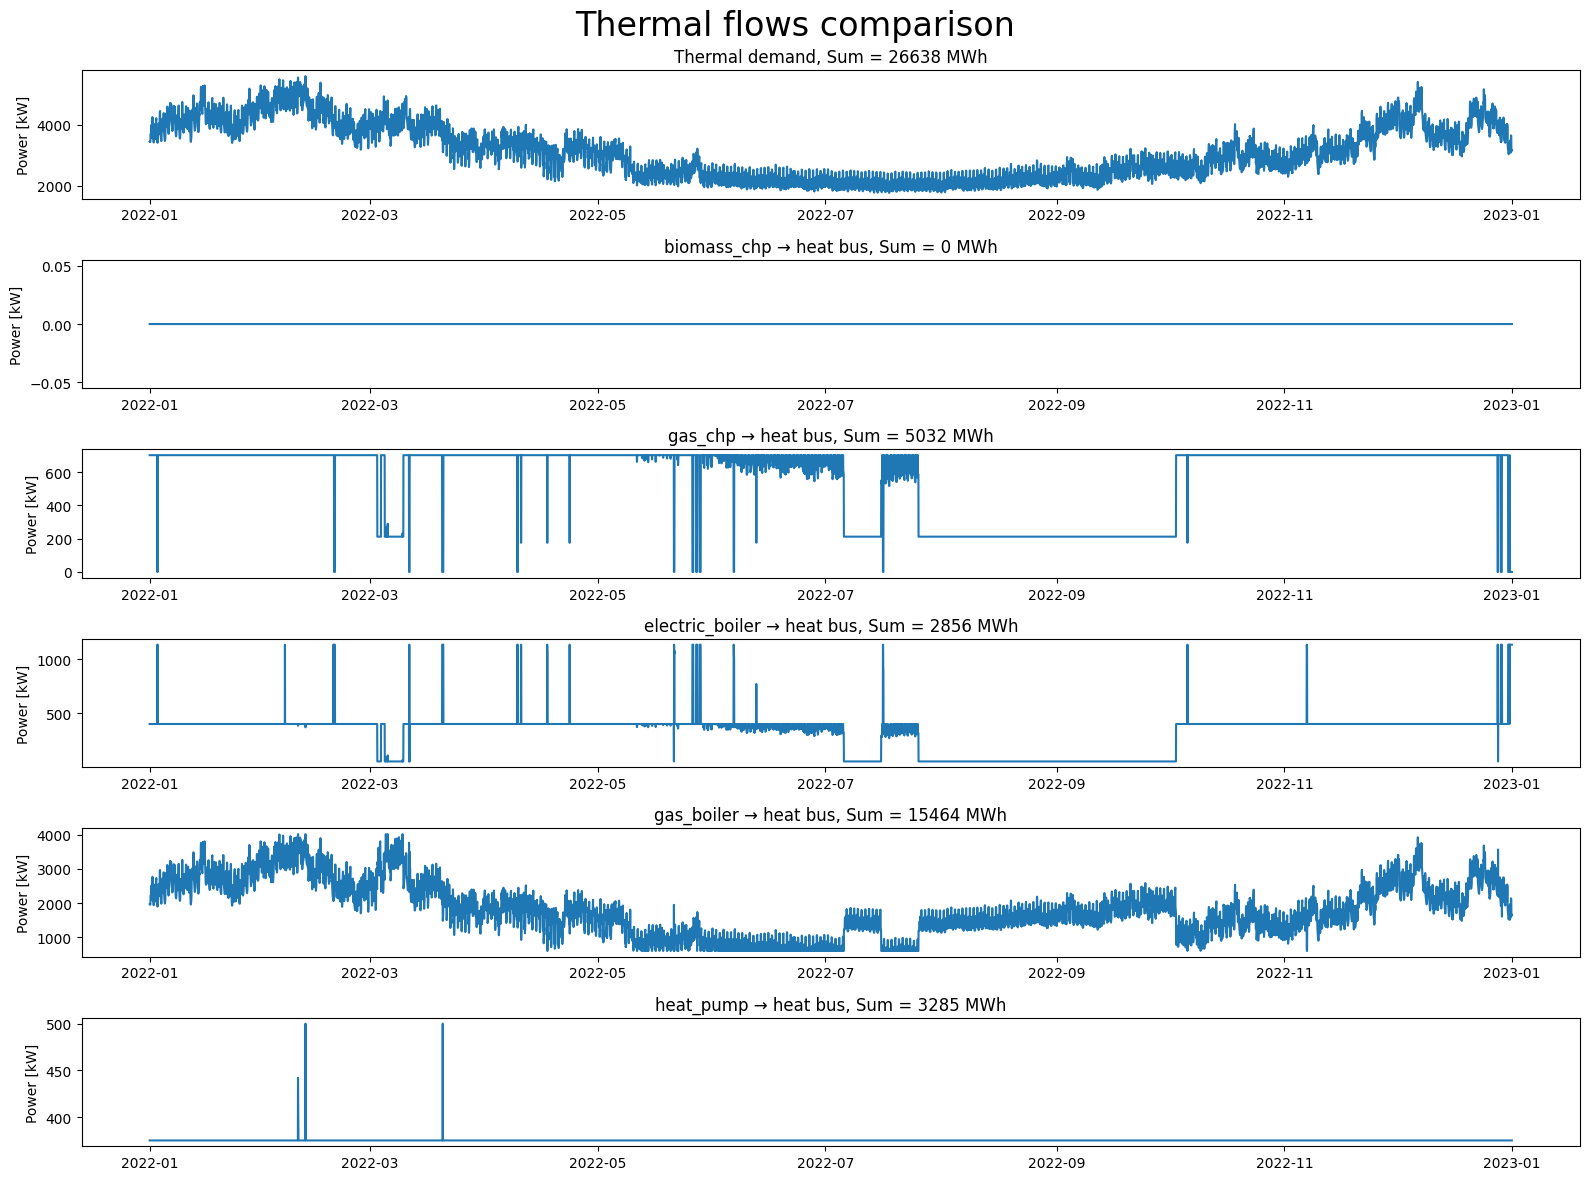

In [6]:
from oemof.solph import views
import matplotlib.pyplot as plt

thermal_sequences = views.node(results_ex, "thermal_bus")["sequences"]
th_demand = thermal_sequences[(('thermal_bus', 'thermal_demand'), 'flow')]
Sum_th_demand = th_demand.sum()
th_biomass_chp = thermal_sequences[(('biomass_chp', 'thermal_bus'), 'flow')]
Sum_th_prod_chp = th_biomass_chp.sum()

th_electric_boiler = thermal_sequences[(('electric_boiler', 'thermal_bus'), 'flow')]
Sum_th_prod_pth = th_electric_boiler.sum()

fig, axs = plt.subplots(3, figsize=(16, 9))
fig.suptitle("Thermal flows comparison", fontsize=24)

axs[0].plot(th_demand)
axs[0].set_title(f"Thermal demand, Sum = {int(Sum_th_demand / 1000)} MWh")

axs[1].plot(th_biomass_chp)
axs[1].set_title(f"Biomass CHP → Heat bus, Sum = {int(Sum_th_prod_chp / 1000)} MWh")

axs[2].plot(th_electric_boiler)
axs[2].set_title(f"Electric boiler → Heat bus, Sum = {int(Sum_th_prod_pth / 1000)} MWh")

for ax in axs:
    ax.set_ylabel("Power [kW]")
    ax.set_xlabel("Time step")

plt.tight_layout()
plt.show()

heat_producers = [
    ('biomass_chp', 'thermal_bus'),
    ('gas_chp', 'thermal_bus'),
    ('electric_boiler', 'thermal_bus'),
    ('gas_boiler', 'thermal_bus'),
    ('heat_pump', 'thermal_bus'),
]

fig, axs = plt.subplots(len(heat_producers) + 1, figsize=(16, 12))
fig.suptitle("Thermal flows comparison", fontsize=24)

# Demand
axs[0].plot(th_demand)
axs[0].set_title(f"Thermal demand, Sum = {int(Sum_th_demand / 1000)} MWh")

# Production
for i, edge in enumerate(heat_producers, start=1):
    if (edge, 'flow') in thermal_sequences:
        series = thermal_sequences[(edge, 'flow')]
        axs[i].plot(series)
        axs[i].set_title(
            f"{edge[0]} → heat bus, Sum = {int(series.sum() / 1000)} MWh"
        )

for ax in axs:
    ax.set_ylabel("Power [kW]")

plt.tight_layout()
plt.show()

In [8]:
from oemof.solph import views
import pandas as pd
# Function to safely get flow
def safe_get_flow(node_results, flow_key):
    try:
        return node_results['sequences'][flow_key]
    except KeyError:
        return 0
    
# Calculate fuel costs - FIXED: Handle length mismatch
def calc_fuel_cost_fixed(flow, price_series):
    if isinstance(flow, (int, float)) and flow == 0:
        return 0
    
    # Convert to numpy arrays
    flow_array = flow.values if hasattr(flow, 'values') else flow
    price_array = price_series.values if hasattr(price_series, 'values') else price_series
    
    # Handle length mismatch - use the minimum length
    min_len = min(len(flow_array), len(price_array))
    
    # Trim both arrays to same length
    flow_array = flow_array[:min_len]
    price_array = price_array[:min_len]
    
    # Multiply element-wise and sum
    return (flow_array * price_array).sum()

# Calculate O&M + CO2 costs (from converter variable costs)
def calc_opcost(flow, var_cost):
    if isinstance(flow, (int, float)) and flow == 0:
        return 0
    return (flow * var_cost).sum()

# Get results for converters
electric_boiler_results = views.node(results_ex, 'electric_boiler')
gas_boiler_results = views.node(results_ex, 'gas_boiler')
heat_pump_results = views.node(results_ex, 'heat_pump')
gas_chp_results = views.node(results_ex, 'gas_chp')
biomass_chp_results = views.node(results_ex, 'biomass_chp')

# Electricity grid import (ONLY place where electricity cost exists)
electricity_bus_seq = views.node(results_ex, "electrical_bus")["sequences"]

grid_electricity_import = safe_get_flow(
    {"sequences": electricity_bus_seq},
    ((("electricity_grid", "electrical_bus"), "flow"))
)

electricity_price = data["electricity_price"] / 1000  # EUR/kWh

grid_electricity_cost = calc_fuel_cost_fixed(
    grid_electricity_import,
    electricity_price
)


# Extract OUTPUT flows from converters
electric_boiler_flow = safe_get_flow(electric_boiler_results, ((('electric_boiler', 'thermal_bus'), 'flow')))
gas_boiler_flow = safe_get_flow(gas_boiler_results, ((('gas_boiler', 'thermal_bus'), 'flow')))
heat_pump_flow = safe_get_flow(heat_pump_results, ((('heat_pump', 'thermal_bus'), 'flow')))
gas_chp_elec_flow = safe_get_flow(gas_chp_results, ((('gas_chp', 'electrical_bus'), 'flow')))
gas_chp_heat_flow = safe_get_flow(gas_chp_results, ((('gas_chp', 'thermal_bus'), 'flow')))
biomass_chp_elec_flow = safe_get_flow(biomass_chp_results, ((('biomass_chp', 'electrical_bus'), 'flow')))
biomass_chp_heat_flow = safe_get_flow(biomass_chp_results, ((('biomass_chp', 'thermal_bus'), 'flow')))

# Extract INPUT flows from converters

electric_boiler_elec_input = safe_get_flow(electric_boiler_results, ((('electrical_bus', 'electric_boiler'), 'flow')))
gas_boiler_gas_input = safe_get_flow(gas_boiler_results, ((('gas_bus', 'gas_boiler'), 'flow')))
heat_pump_elec_input = safe_get_flow(heat_pump_results, ((('electrical_bus', 'heat_pump'), 'flow')))
gas_chp_gas_input = safe_get_flow(gas_chp_results, ((('gas_bus', 'gas_chp'), 'flow')))
biomass_chp_biomass_input = safe_get_flow(biomass_chp_results, ((('bio_bus', 'biomass_chp'), 'flow')))



opcost_electric_boiler = calc_opcost(electric_boiler_flow, 0.8e-3 + emission_factor_grid_EB * co2_price / 1000)
opcost_gas_boiler = calc_opcost(gas_boiler_flow, 1.1e-3 + emission_factor_chp * co2_price / 1000)
opcost_heat_pump = calc_opcost(heat_pump_flow, 3.75e-3 + emission_factor_grid_HP * co2_price / 1000)
opcost_gas_chp = calc_opcost(gas_chp_elec_flow, 5.5e-3 + emission_factor_chp * co2_price / 1000)
opcost_biomass_chp = calc_opcost(biomass_chp_elec_flow, 3.9e-3 + emission_factor_biomass * co2_price / 1000)



# CORRECTED: Divide electricity_price by 1000 to convert EUR/MWh to EUR/kWh
fuel_cost_electric_boiler = 0.0
fuel_cost_gas_boiler = calc_fuel_cost_fixed(gas_boiler_gas_input, data["gas_price"] / 1000)
fuel_cost_heat_pump = 0.0
fuel_cost_gas_chp = calc_fuel_cost_fixed(gas_chp_gas_input, data["gas_price"] / 1000)
fuel_cost_biomass_chp = calc_fuel_cost_fixed(biomass_chp_biomass_input, data["wp_price"])

# Calculate total operational costs
total_opcost_electric_boiler = opcost_electric_boiler + fuel_cost_electric_boiler
total_opcost_gas_boiler = opcost_gas_boiler + fuel_cost_gas_boiler
total_opcost_heat_pump = opcost_heat_pump + fuel_cost_heat_pump
total_opcost_gas_chp = opcost_gas_chp + fuel_cost_gas_chp
total_opcost_biomass_chp = opcost_biomass_chp + fuel_cost_biomass_chp

# Print results
print("\n" + "="*60)
print("OPERATIONAL COSTS (O&M + CO2 + Fuel)")
print("="*60)
print(f"Electric Boiler:  {total_opcost_electric_boiler:,.2f} EUR")
print(f"Gas Boiler:       {total_opcost_gas_boiler:,.2f} EUR")
print(f"Heat Pump:        {total_opcost_heat_pump:,.2f} EUR")
print(f"Gas CHP:          {total_opcost_gas_chp:,.2f} EUR")
print(f"Biomass CHP:      {total_opcost_biomass_chp:,.2f} EUR")

print("\nELECTRICITY GRID COST")
print("-"*60)
print(f"Grid electricity import cost: {grid_electricity_cost:,.2f} EUR")


print("="*60)
total_all = (total_opcost_electric_boiler + total_opcost_gas_boiler + 
             total_opcost_heat_pump + total_opcost_gas_chp + total_opcost_biomass_chp+grid_electricity_cost)
print(f"TOTAL:            {total_all:,.2f} EUR")
print("="*60)


# Detailed breakdown
print("\nDETAILED BREAKDOWN:")
print("-"*60)

plants = [
    ("Electric Boiler", opcost_electric_boiler, fuel_cost_electric_boiler),
    ("Gas Boiler", opcost_gas_boiler, fuel_cost_gas_boiler),
    ("Heat Pump", opcost_heat_pump, fuel_cost_heat_pump),
    ("Gas CHP", opcost_gas_chp, fuel_cost_gas_chp),
    ("Biomass CHP", opcost_biomass_chp, fuel_cost_biomass_chp)
]

for plant_name, om_co2_cost, fuel_cost in plants:
    total = om_co2_cost + fuel_cost
    if total > 0:
        print(f"\n{plant_name}:")
        print(f"  O&M + CO2: {om_co2_cost:,.2f} EUR")
        print(f"  Fuel:      {fuel_cost:,.2f} EUR")
        print(f"  Total:     {total:,.2f} EUR")
    else:
        print(f"\n{plant_name}: NOT USED (0.00 EUR)")

# Energy production summary
print("\n" + "="*60)
print("ENERGY PRODUCTION SUMMARY")
print("="*60)

def calc_total(flow):
    if isinstance(flow, (int, float)) and flow == 0:
        return 0
    return flow.sum()

print(f"Electric Boiler Heat:    {calc_total(electric_boiler_flow):,.2f} kWh")
print(f"Gas Boiler Heat:         {calc_total(gas_boiler_flow):,.2f} kWh")
print(f"Heat Pump Heat:          {calc_total(heat_pump_flow):,.2f} kWh")
print(f"Gas CHP Heat:            {calc_total(gas_chp_heat_flow):,.2f} kWh")
print(f"Gas CHP Electricity:     {calc_total(gas_chp_elec_flow):,.2f} kWh")
print(f"Biomass CHP Heat:        {calc_total(biomass_chp_heat_flow):,.2f} kWh")
print(f"Biomass CHP Electricity: {calc_total(biomass_chp_elec_flow):,.2f} kWh")
print("="*60)

cost_df = pd.DataFrame({
    "O&M + CO2 [EUR]": [
        opcost_electric_boiler,
        opcost_gas_boiler,
        opcost_heat_pump,
        opcost_gas_chp,
        opcost_biomass_chp,
        0.0  # grid has no O&M
    ],
    "Fuel / Energy [EUR]": [
        fuel_cost_electric_boiler,
        fuel_cost_gas_boiler,
        fuel_cost_heat_pump,
        fuel_cost_gas_chp,
        fuel_cost_biomass_chp,
        grid_electricity_cost
    ],
}, index=[
    "Electric Boiler",
    "Gas Boiler",
    "Heat Pump",
    "Gas CHP",
    "Biomass CHP",
    "Electricity Grid Import"
])

cost_df["Total Operational Cost [EUR]"] = (
    cost_df["O&M + CO2 [EUR]"] + cost_df["Fuel / Energy [EUR]"]
)

cost_df.loc["TOTAL"] = cost_df.sum()

output_dir = os.path.join(os.getcwd(), "Output_file_S3")
os.makedirs(output_dir, exist_ok=True)

excel_path = os.path.join(output_dir, "operational_costs.xlsx")

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    cost_df.to_excel(writer, sheet_name="Operational costs")

print(f"Operational costs exported to:\n{excel_path}")


OPERATIONAL COSTS (O&M + CO2 + Fuel)
Electric Boiler:  10,261.90 EUR
Gas Boiler:       2,651,155.69 EUR
Heat Pump:        14,591.99 EUR
Gas CHP:          1,261,824.10 EUR
Biomass CHP:      0.00 EUR

ELECTRICITY GRID COST
------------------------------------------------------------
Grid electricity import cost: -170.98 EUR
TOTAL:            3,937,662.70 EUR

DETAILED BREAKDOWN:
------------------------------------------------------------

Electric Boiler:
  O&M + CO2: 10,261.90 EUR
  Fuel:      0.00 EUR
  Total:     10,261.90 EUR

Gas Boiler:
  O&M + CO2: 856,688.83 EUR
  Fuel:      1,794,466.86 EUR
  Total:     2,651,155.69 EUR

Heat Pump:
  O&M + CO2: 14,591.99 EUR
  Fuel:      0.00 EUR
  Total:     14,591.99 EUR

Gas CHP:
  O&M + CO2: 214,103.19 EUR
  Fuel:      1,047,720.91 EUR
  Total:     1,261,824.10 EUR

Biomass CHP: NOT USED (0.00 EUR)

ENERGY PRODUCTION SUMMARY
Electric Boiler Heat:    2,856,081.86 kWh
Gas Boiler Heat:         15,464,836.18 kWh
Heat Pump Heat:          3,285,